# Evaluation of a selection of models on 60km -> 2.2km-4x over Birmingham

In [ ]:
%reload_ext autoreload

%autoreload 2

%reload_ext dotenv
%dotenv

In [ ]:
from mlde_analysis.default_params import *

In [ ]:
# Parameters
desc = "Comparison of diffusion models trained on just 1 ensemble member and one time period vs 1 ensemble member and three time periods\nTest split\n12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set\nCompare techniques: diffusion, u-net, bilinear\n\nEvaluated on all 3 time periods but just 1 ensemble member\n"
split = "test"
ensemble_members = ["01"]
samples_per_run = 6
dataset_configs = {"CPM": "bham64_ccpm-4x_1em_psl-sphum4th-temp4th-vort4th_pr"}
sample_configs = {
    "CPM": [
        {
            "label": "cCPM 1em 1TP",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_1em_cncsnpp_continuous/bham-4x_1em_pSTV_lowdata",
                    "checkpoint": "epoch_300",
                    "config_hash": "36f1d4f988b7e2c0",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "input_xfm": "bham64_ccpm-4x_1em_psl-sphum4th-temp4th-vort4th_pr-historic-stan",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "Samples": True,
            "CCS": True,
            "color": "tab:red",
            "order": 10,
        },
        {
            "label": "cCPM 1em 3TP",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_1em_cncsnpp_continuous/bham-4x_1em_pSTV",
                    "checkpoint": "epoch_120",
                    "config_hash": "8a88ee169ecf997e",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "input_xfm": "bham64_ccpm-4x_1em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "Samples": True,
            "CCS": True,
            "color": "tab:orange",
            "order": 15,
        },
        {
            "label": "cCPM 12em 3TP",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:blue",
            "order": 20,
        },
    ]
}


In [ ]:
import functools
import math
import string

import IPython
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr

from mlde_analysis.utils import chained_groupby_map
from mlde_analysis.data import prep_eval_data
from mlde_analysis import plot_map
from mlde_analysis.bootstrap import resample_examples
from mlde_analysis.ccs import compute_changes, plot_changes, plot_tp_fd, plot_hist_per_tp, plot_ccs_fc_figure, ccs_fc_da
from mlde_analysis.distribution import PER_GRIDBOX_QUANTILES, normalized_mean_bias, normalized_std_bias, plot_freq_density, rms_mean_bias, rms_std_bias, compute_metrics, DIST_THRESHOLDS
from mlde_analysis.fractional_contribution import compute_fractional_contribution, frac_contrib_change, fc_bins
from mlde_analysis.wet_dry import threshold_exceeded_prop_stats, threshold_exceeded_prop_change, plot_threshold_exceedence_errors, THRESHOLDS
from mlde_analysis.display import VAR_RANGES, pretty_table
from mlde_utils import cp_model_rotated_pole, TIME_PERIODS

In [ ]:
matplotlib.rcParams['figure.dpi'] = 300

In [ ]:
IPython.display.Markdown(desc)

Comparison of diffusion models trained on just 1 ensemble member and one time period vs 1 ensemble member and three time periods
Test split
12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set
Compare techniques: diffusion, u-net, bilinear

Evaluated on all 3 time periods but just 1 ensemble member


In [ ]:
%reload_ext mlde_analysis.magics 
EVAL_DS, MODELS, CPM_DAS, PRED_DAS, VAR_DAS, MODELLABEL2SPEC = %load_eval_data
EVAL_DS

{'CPM': <xarray.Dataset> Size: 2GB
 Dimensions:                     (model: 3, sample_id: 6, ensemble_member: 1,
                                  time: 3240, grid_latitude: 64,
                                  grid_longitude: 64, bnds: 2)
 Coordinates:
   * time                        (time) object 26kB 1981-03-01 12:00:00 ... 20...
     season                      (time) float64 26kB 1.0 1.0 1.0 ... 2.0 2.0 2.0
   * grid_latitude               (grid_latitude) float32 256B -2.49 ... 2.55
   * grid_longitude              (grid_longitude) float32 256B 357.9 ... 363.0
   * ensemble_member             (ensemble_member) <U2 8B '01'
   * model                       (model) object 24B 'cCPM 1em 1TP' ... 'cCPM 1...
     time_period                 (time) <U8 104kB 'historic' ... 'future'
     dec_adjusted_year           (time) int64 26kB 1981 1981 1981 ... 2076 2076
     stratum                     (time) <U12 156kB 'historic MAM' ... 'future ...
     tp_season_year              (time) <U17 

In [ ]:
CCS_SEASONS = ["DJF", "JJA"]

In [ ]:
CCS_MODELS = {source: {model: spec for model, spec in mconfigs.items() if spec.get("CCS", False)} for source, mconfigs in MODELS.items() }

CCS_PRED_DAS = {var: PRED_DAS[var].sel(model=list([model for source, models in CCS_MODELS.items() for model in models])) for var in eval_vars }

CCS_DS = xr.combine_by_coords([*list(CPM_DAS.values()), *list(CCS_PRED_DAS.values())])

## Figure: Climate change signal

* Per time period freq density histogram
* Mean change diff: $(\mu_{{ML}}^{{future}} - \mu_{{ML}}^{{hist}})/\mu_{{ML}}^{{hist}} - (\mu_{{CPM}}^{{future}} - \mu_{{CPM}}^{{hist}})/\mu_{{CPM}}^{{hist}}$

#### pr

##### cCPM 12em 3TP

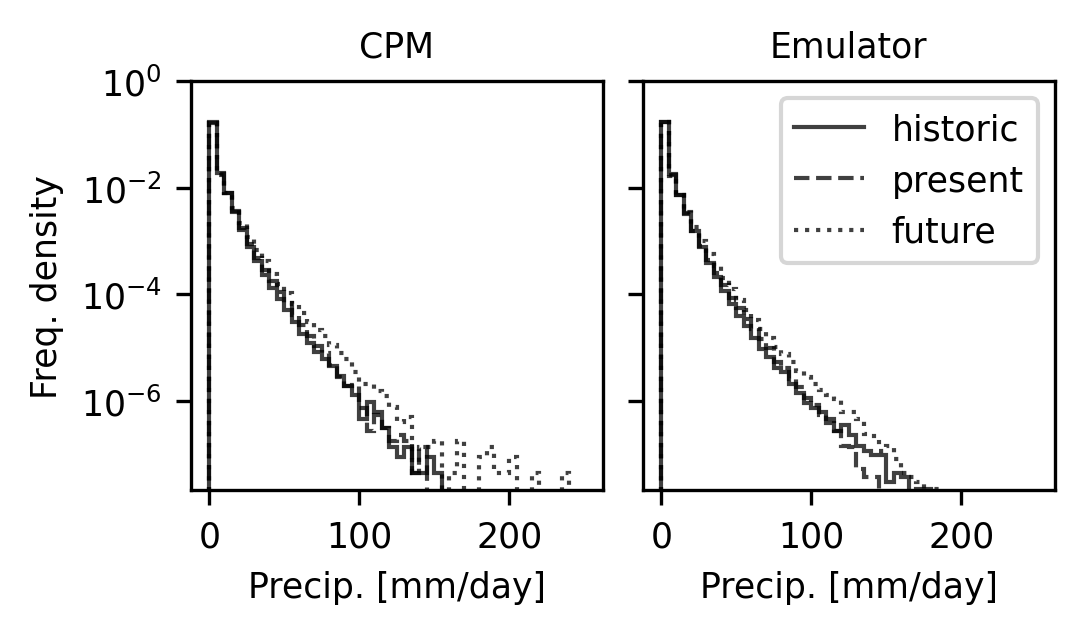

##### cCPM 1em 1TP

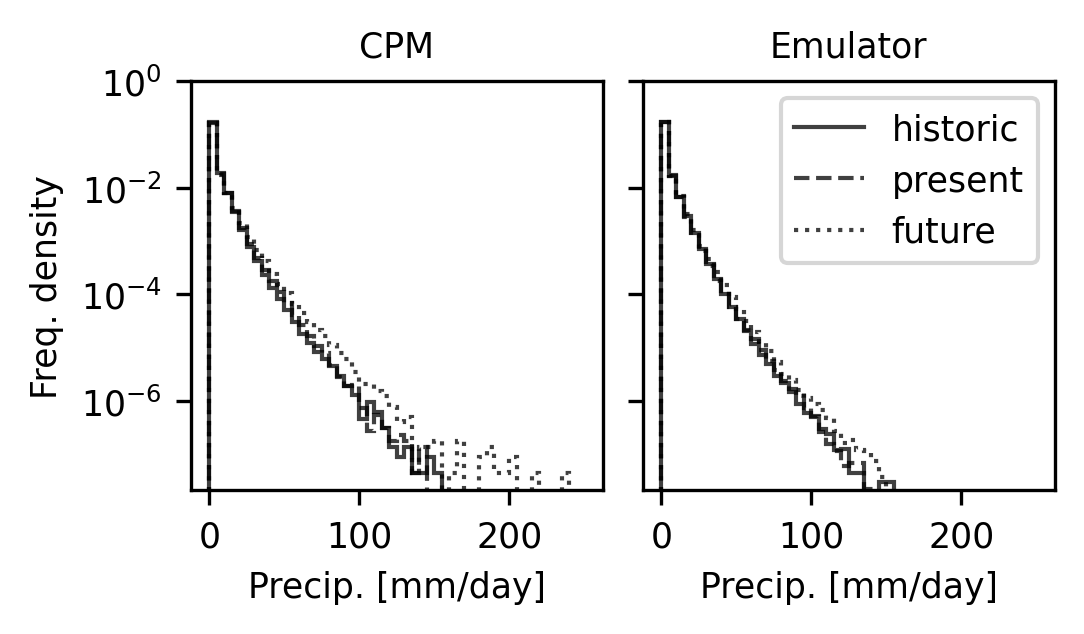

##### cCPM 1em 3TP

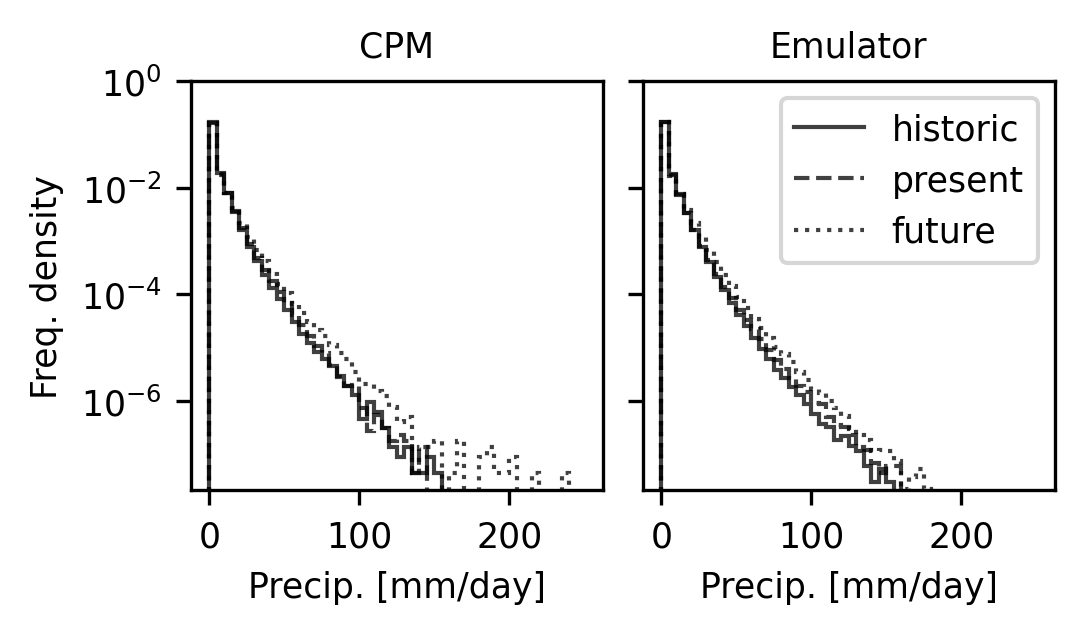

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"#### {var}", raw=True)
    for model, model_ds in CCS_DS.groupby("model"):
        IPython.display.display_markdown(f"##### {model}", raw=True)

        pred_da = model_ds[f"pred_{var}"]
        cpm_da = model_ds[f"target_{var}"]
        
        fig, axd = plt.subplot_mosaic([["cpm", "model"]], figsize=(3.5, 2), constrained_layout=True, sharex=True, sharey=True)
        
        hrange=VAR_RANGES[var]
        plot_hist_per_tp(cpm_da, axd["cpm"], title="CPM",  hrange=hrange, legend=False)
        plot_hist_per_tp(pred_da, axd["model"], title="Emulator", hrange=hrange)
        axd["model"].set_ylabel(None)

        plt.show()

#### pr

##### cCPM 12em 3TP

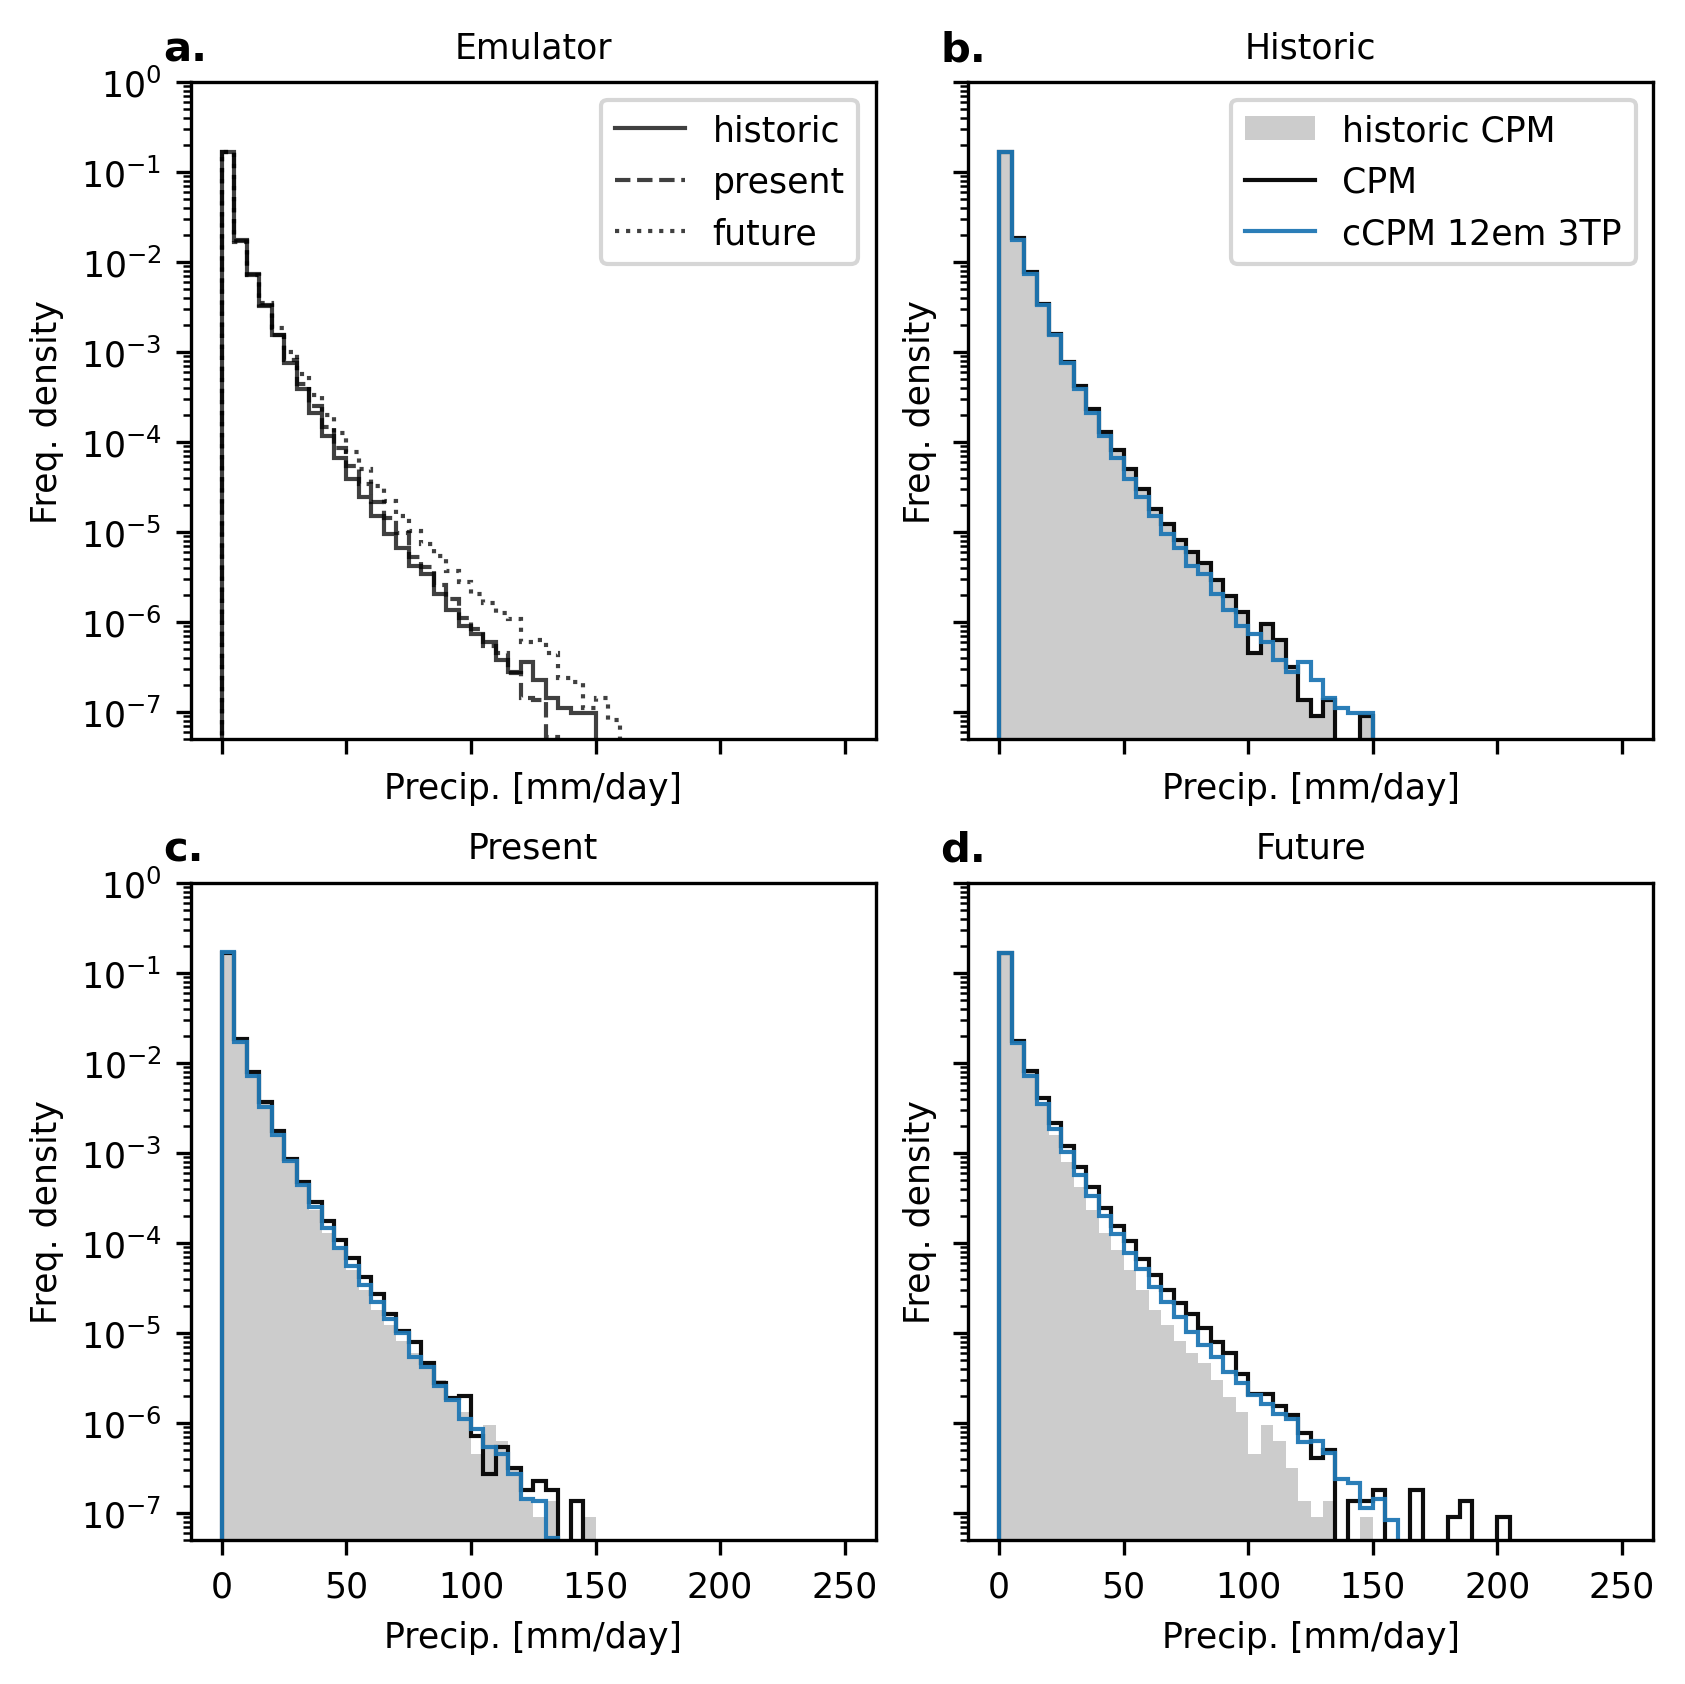

##### cCPM 1em 1TP

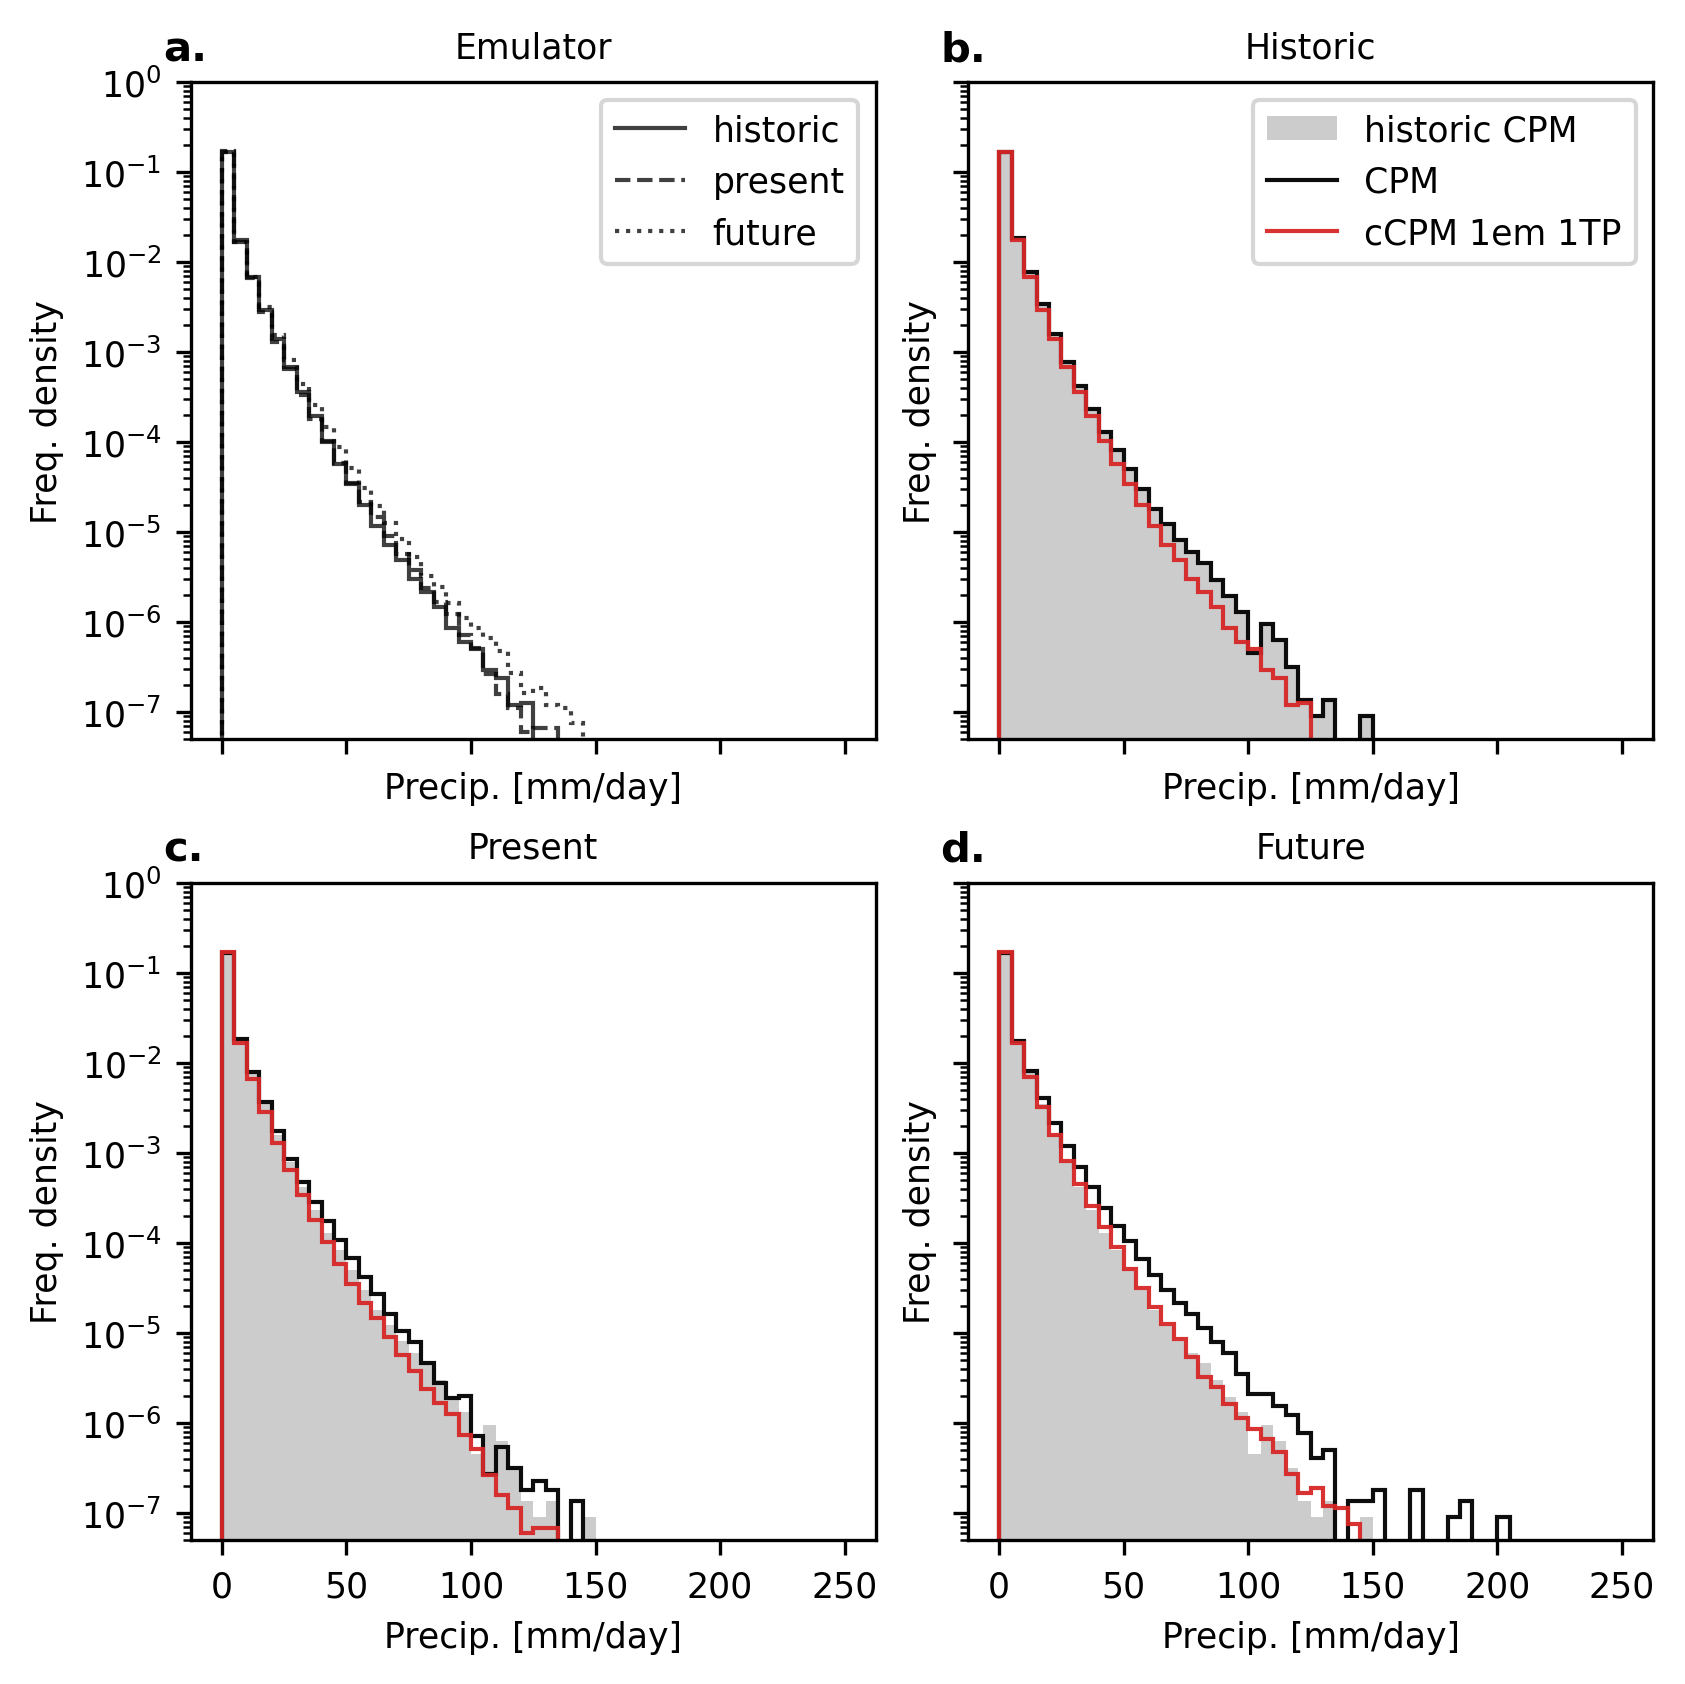

##### cCPM 1em 3TP

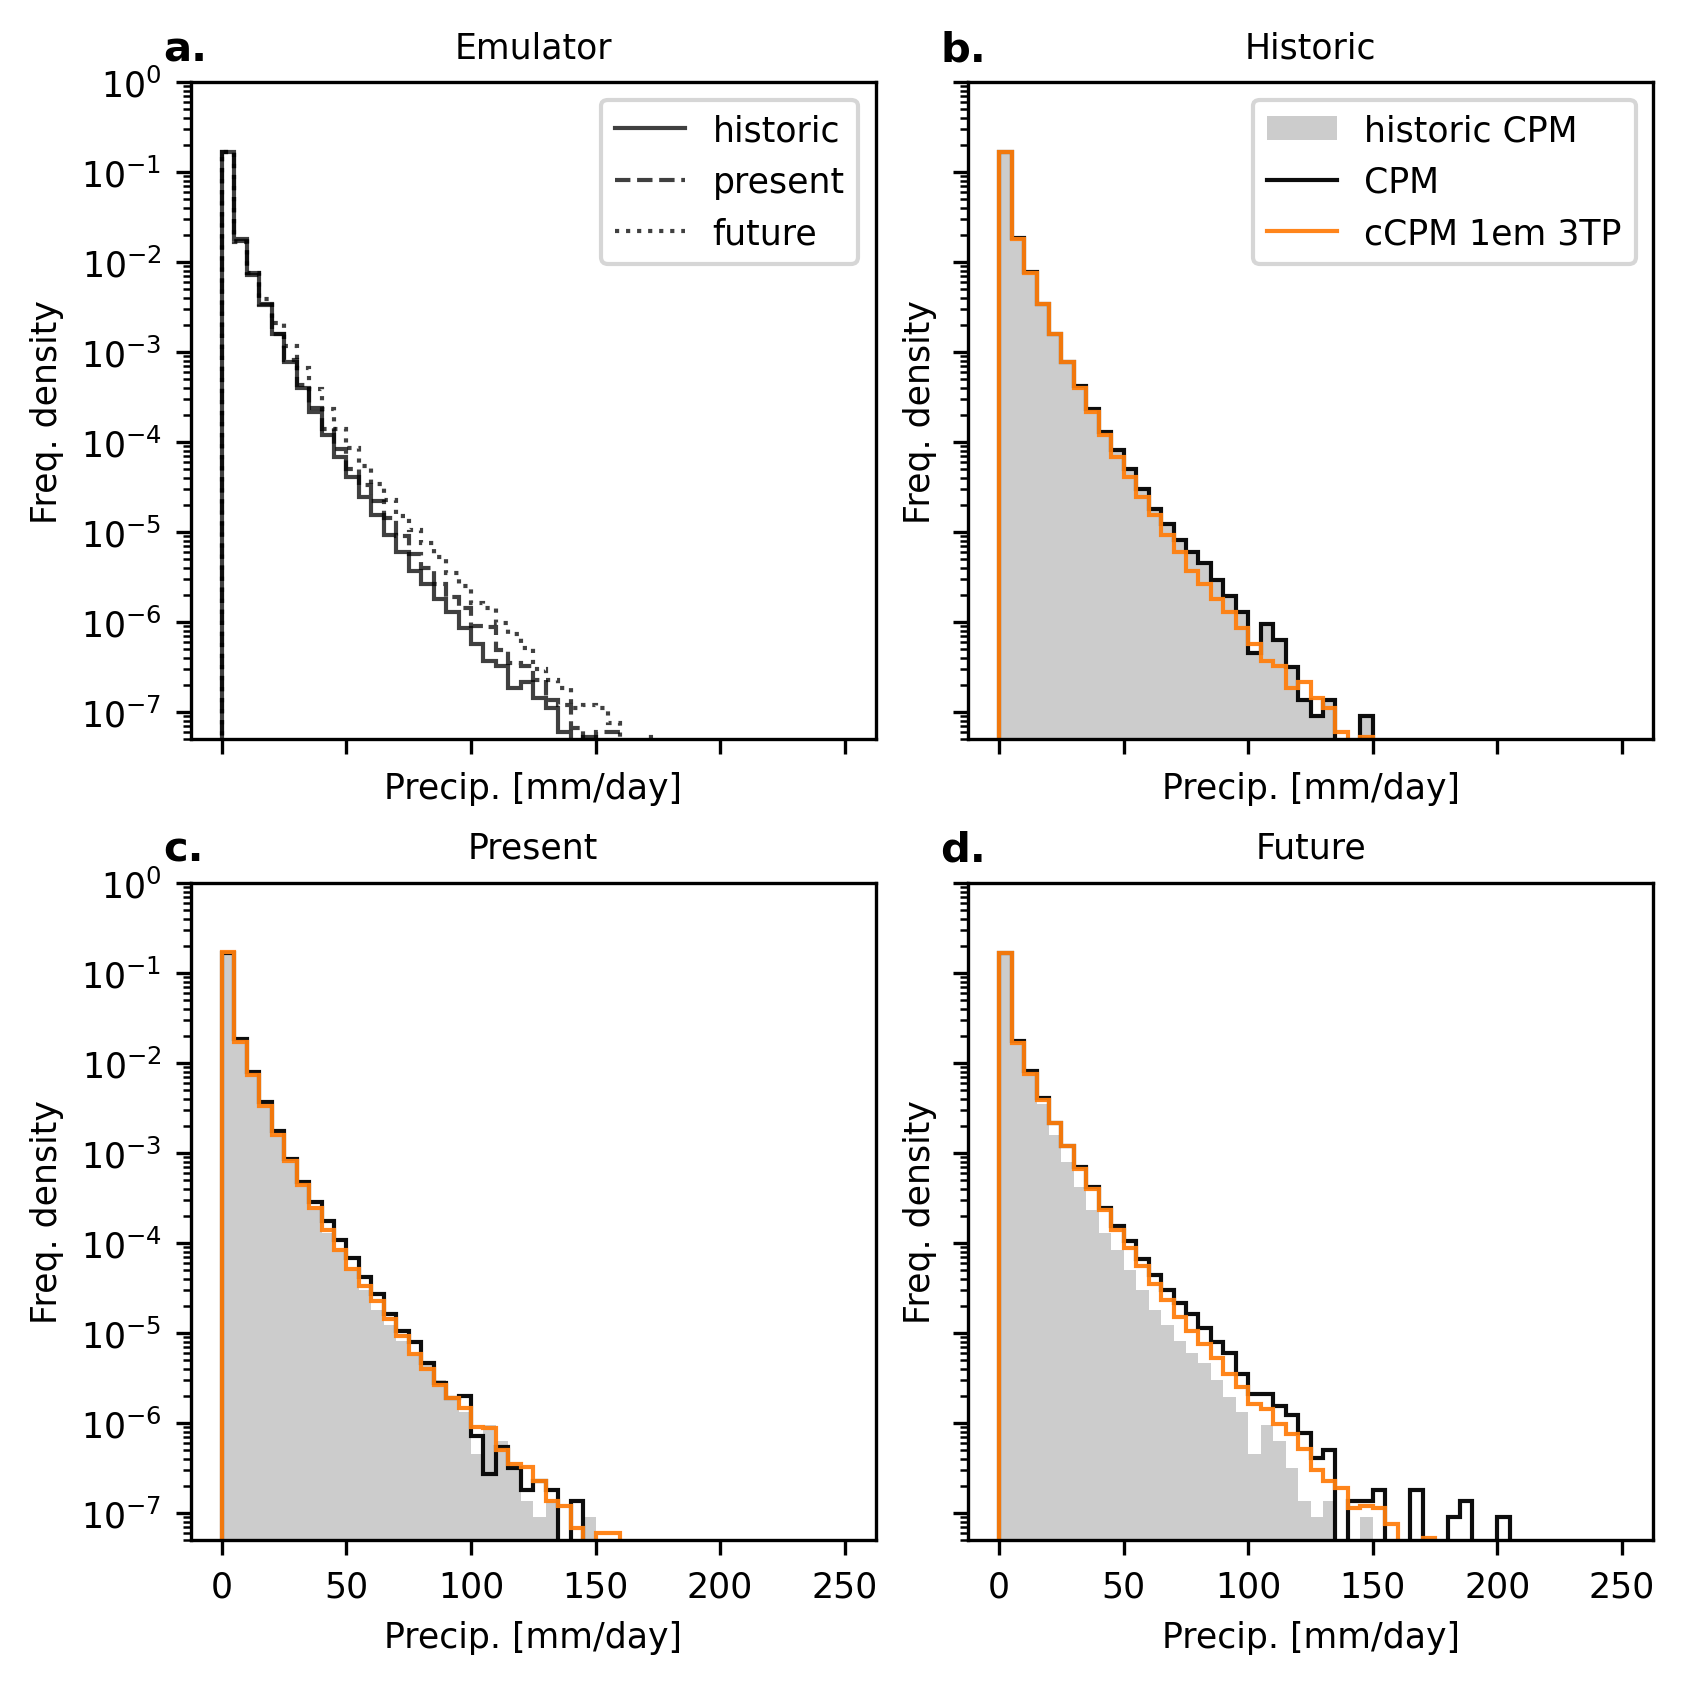

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"#### {var}", raw=True)
    for model, model_ds in CCS_DS.groupby("model"):
        IPython.display.display_markdown(f"##### {model}", raw=True)

        fd_fig = plt.figure(figsize=(5.5, 5.5), layout="compressed")
        pred_da = model_ds[f"pred_{var}"]

        if var == "pr":
            hrange = (0, 250)
        else:
            hrange = None
        plot_tp_fd(pred_da, CPM_DAS[var], fd_fig, MODELLABEL2SPEC[model]["source"], model, MODELLABEL2SPEC[model], hrange=hrange)

        plt.show()

## Figure: per Time Period distribution

* Frequency Density Histogram of rainfall intensities for each time period

#### pr

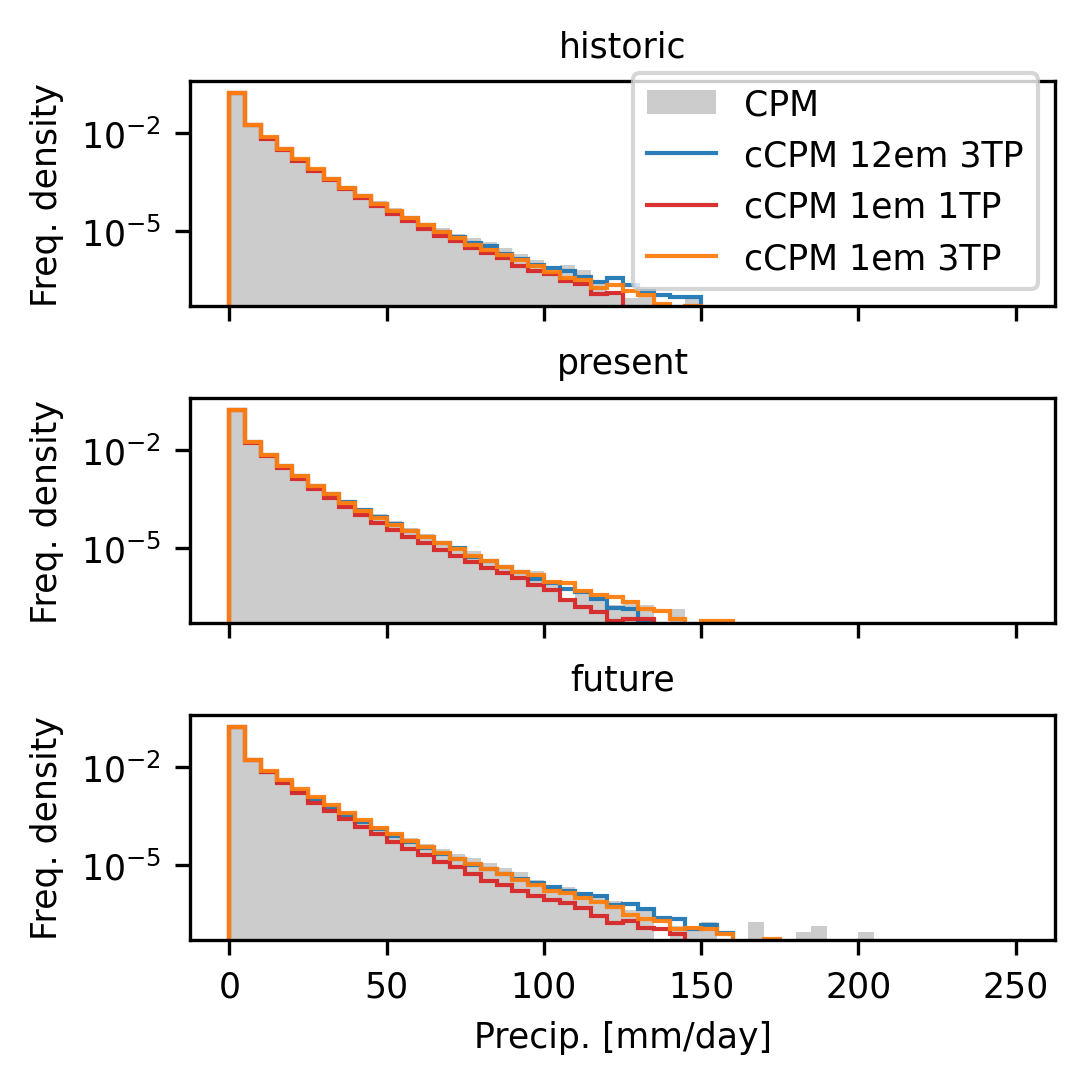

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"#### {var}", raw=True)
    
    fig = plt.figure(layout='constrained', figsize=(3.5, 3.5))
        
    # labels = [ label for mconfigs in MODELS.values() for label in mconfigs.keys() ]
    
    # meanb_axes_keys = list(map(lambda x: f"meanb {x}", labels))
    # meanb_spec = np.array(meanb_axes_keys).reshape(1,-1)
    
    # stddevb_axes_keys = list(map(lambda x: f"stddevb {x}", labels))
    # stddevb_spec = np.array(stddevb_axes_keys).reshape(1,-1)
    
    dist_spec = np.array(list(TIME_PERIODS.keys())).reshape(-1,1)
    
    spec = dist_spec
    
    axd = fig.subplot_mosaic(spec, sharex=True, sharey=True)#, gridspec_kw=dict(height_ratios=[3, 2, 2]), per_subplot_kw={ak: {"projection": cp_model_rotated_pole} for ak in meanb_axes_keys + stddevb_axes_keys})
    
    for tp_key, tp_ds in CCS_DS.groupby("time_period"):
        ax = axd[tp_key]
    
        hist_data = [ dict(data=model_ds[f"pred_{var}"], label=model, color=MODELLABEL2SPEC[model]["color"]) for model, model_ds in tp_ds.groupby("model") ]
        hrange=VAR_RANGES[var]
        plot_freq_density(hist_data, ax=ax, target_da=tp_ds[f"target_{var}"], legend=(tp_key=="historic"), linewidth=1, title=tp_key, hrange=hrange)

        ax.xaxis.label.set_visible(tp_key == "future")    

    plt.show()

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)

    metrics_ds = CCS_DS.groupby("time_period").map(lambda tp_ds: compute_metrics(tp_ds[f"pred_{var}"], tp_ds[f"target_{var}"], thresholds=DIST_THRESHOLDS[var]))
    pretty_table(metrics_ds, round=4, dim_order=["time_period", "model"])

### pr

NaN Count 
 RMS Mean Bias (mm/day) 
 RMS Std Dev Bias (mm/day) 
 Relative RMS Mean Bias (%) 
 Relative RMS Std Dev Bias (%) 
 J-S distance 
 Emu > 0.1 
 Emu > 0.1 - CPM > 0.1 
 Emu > 25 
 Emu > 25 - CPM > 25 
 Emu > 75 
 Emu > 75 - CPM > 75 
 Emu > 125 
 Emu > 125 - CPM > 125 
 
 
 time_period 
 model 
   
   
   
   
   
   
   
   
   
   
   
   
   
   
 
 
 
 
 future 
 cCPM 12em 3TP 
 0 
 0.2927 
 0.651 
 11.04 
 10.53 
 0.01708 
 0.5121 
 -0.008558 
 0.01245 
 -0.002689 
 0.0001918 
 -8.195e-05 
 1.04e-05 
 -2.261e-07 
 
 
 cCPM 1em 1TP 
 0 
 0.4739 
 1.136 
 17.93 
 18.87 
 0.02864 
 0.5017 
 -0.01893 
 0.009509 
 -0.005629 
 8.447e-05 
 -0.0001893 
 3.014e-06 
 -7.611e-06 
 
 
 cCPM 1em 3TP 
 0 
 0.1707 
 0.5215 
 6.339 
 8.519 
 0.008622 
 0.5147 
 -0.005939 
 0.01436 
 -0.0007725 
 0.0001799 
 -9.381e-05 
 6.593e-06 
 -4.031e-06 
 
 
 historic 
 cCPM 12em 3TP 
 0 
 0.1465 
 0.3732 
 5.717 
 7.262 
 0.008081 
 0.5391 
 -0.0001739 
 0.008298 
 -0.0006481 
 7.637e-05 
 -2.264e-05 
 4.408e-06 
 2.148e-06 
 
 
 cCPM 1em 1TP 
 0 
 0.2565 
 0.5427 
 10.84 
 10.87 
 0.01605 
 0.5276 
 -0.0117 
 0.007502 
 -0.001444 
 4.792e-05 
 -5.109e-05 
 9.796e-07 
 -1.281e-06 
 
 
 cCPM 1em 3TP 
 0 
 0.1517 
 0.3982 
 5.538 
 7.571 
 0.004946 
 0.5401 
 0.0008557 
 0.008457 
 -0.0004895 
 6.299e-05 
 -3.602e-05 
 2.374e-06 
 1.13e-07 
 
 
 present 
 cCPM 12em 3TP 
 0 
 0.2123 
 0.4396 
 8.765 
 8.411 
 0.01386 
 0.5128 
 -0.01106 
 0.009468 
 -0.001035 
 8.824e-05 
 -2.163e-05 
 1.658e-06 
 -1.281e-06 
 
 
 cCPM 1em 1TP 
 0 
 0.4053 
 0.8423 
 17.03 
 16.74 
 0.02692 
 0.4981 
 -0.02578 
 0.007113 
 -0.00339 
 5.576e-05 
 -5.41e-05 
 1.017e-06 
 -1.921e-06 
 
 
 cCPM 1em 3TP 
 0 
 0.2105 
 0.4675 
 8.9 
 9.178 
 0.0129 
 0.5137 
 -0.01011 
 0.00934 
 -0.001163 
 9.754e-05 
 -1.232e-05 
 3.843e-06 
 9.042e-07

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)
    
    quantiles_da = xr.concat([
        chained_groupby_map(
            CCS_DS[f"pred_{var}"], 
            ["model", "time_period"], 
            lambda gda: gda.quantile(q=PER_GRIDBOX_QUANTILES, dim=["ensemble_member", "time", "sample_id"])
        ),
        chained_groupby_map(
            CCS_DS[f"target_{var}"], 
            ["time_period"], 
            lambda gda: gda.quantile(q=PER_GRIDBOX_QUANTILES, dim=["ensemble_member", "time"])
        ).expand_dims(model=["CPM"])],
        dim="model",
    )
    
    quantiles_change_da = (100*(quantiles_da.sel(time_period="future") - quantiles_da.sel(time_period="historic")) / quantiles_da.sel(time_period="historic")).drop_vars("time_period").rename("Relative change in quantile [%]")
    
    pretty_table(
        quantiles_change_da.mean(["grid_latitude", "grid_longitude"]), 
        round=2, 
        caption="Domain mean of annual quantile changes",
        dim_order=["quantile", "model"],
    )

### pr

Domain mean of annual quantile changes 
 
 
   
   
 Relative change in quantile [%] 
 
 
 quantile 
 model 
   
 
 
 
 
 0.990000 
 cCPM 1em 1TP 
 7.7 
 
 
 cCPM 1em 3TP 
 22 
 
 
 cCPM 12em 3TP 
 15 
 
 
 CPM 
 22 
 
 
 0.999000 
 cCPM 1em 1TP 
 10 
 
 
 cCPM 1em 3TP 
 22 
 
 
 cCPM 12em 3TP 
 17 
 
 
 CPM 
 21

## Figure: Fractional contribution

* Fractional contribution of rainfall intensities for each time period
* Change in fractional contribution of rainfall intensities from historic to future

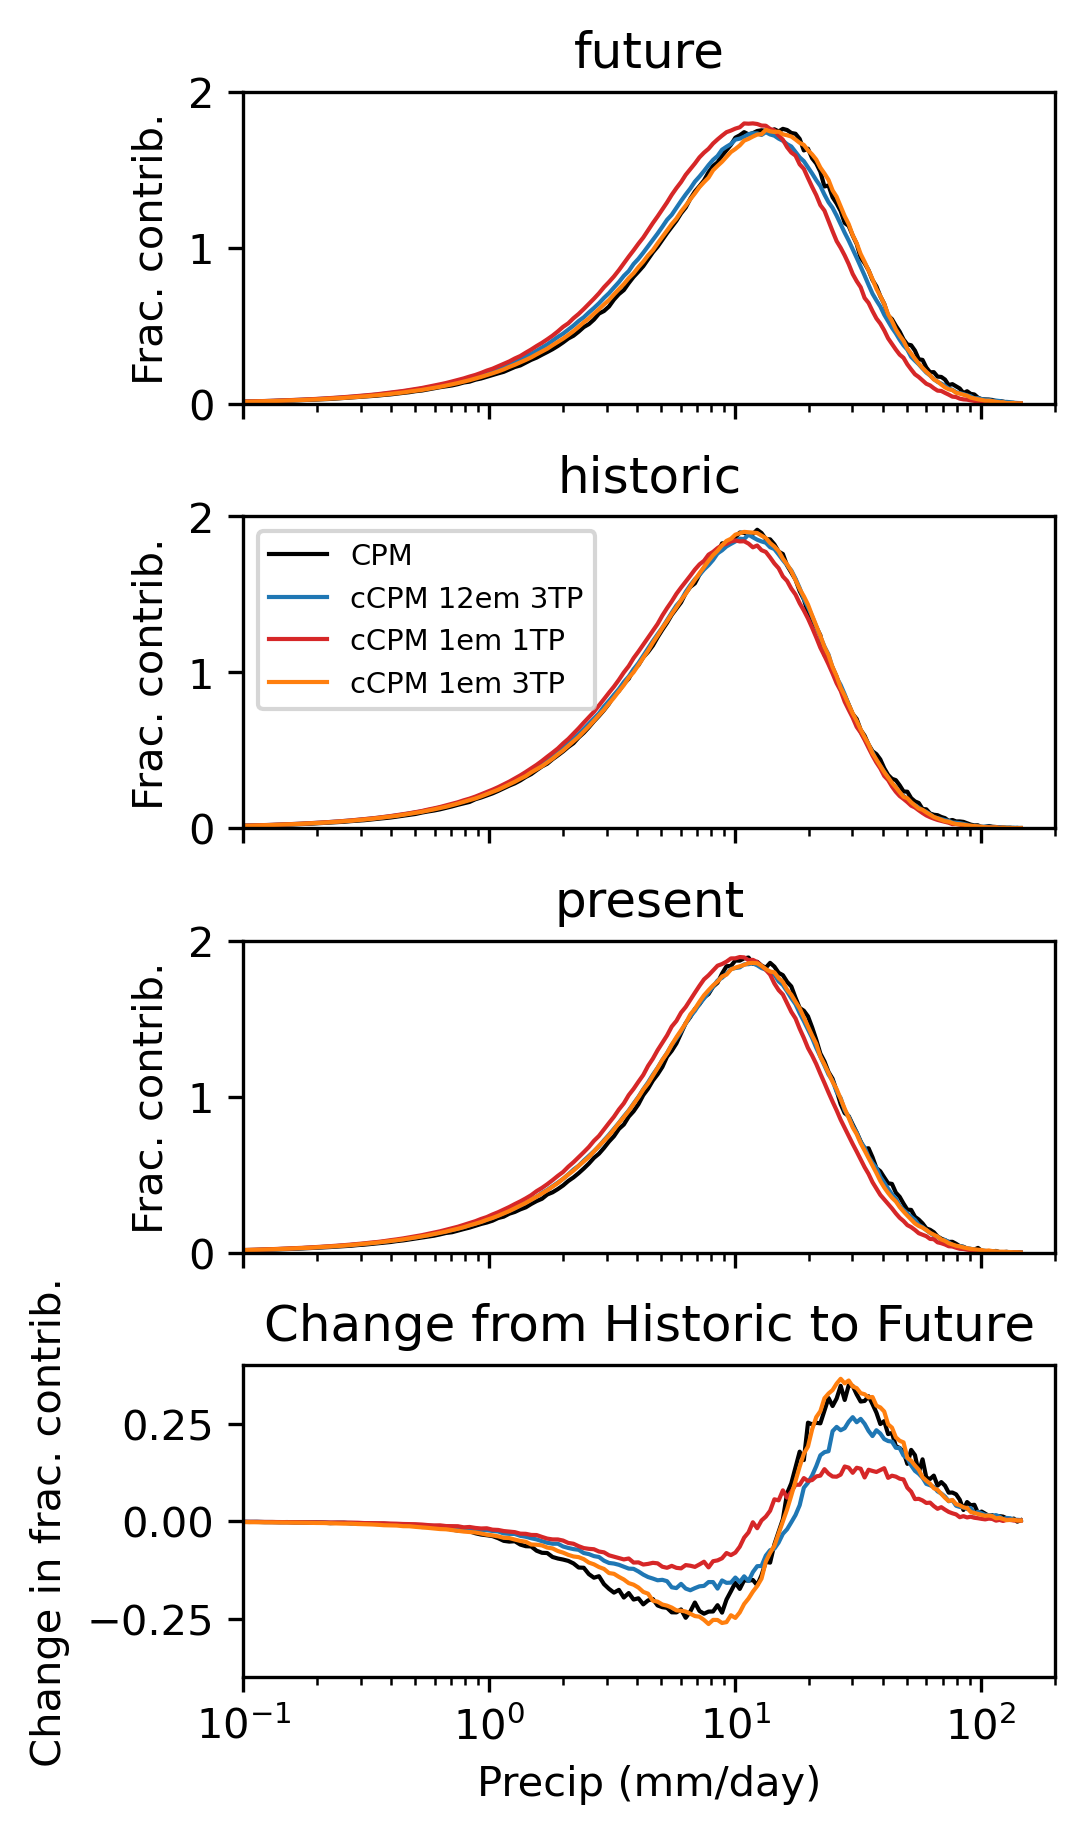

In [ ]:
for var in eval_vars:
    if var not in ["pr"]:
        continue
    
    fcdata = ccs_fc_da(CCS_DS[f"pred_{var}"], CCS_DS[f"target_{var}"])
    fig = plt.figure(layout='constrained', figsize=(3.5, 6))
    plot_ccs_fc_figure(fig, fcdata, palette={label: spec["color"] for label, spec in MODELLABEL2SPEC.items()})
    plt.show()

### Bootstrapped fractional contributions

In [ ]:
import gc

bs_cpm_das = { var: chained_groupby_map(CCS_DS[f"target_{var}"], ["time_period", "time.season"], resample_examples, niterations=niterations) for var in eval_vars if var in ["pr"] }

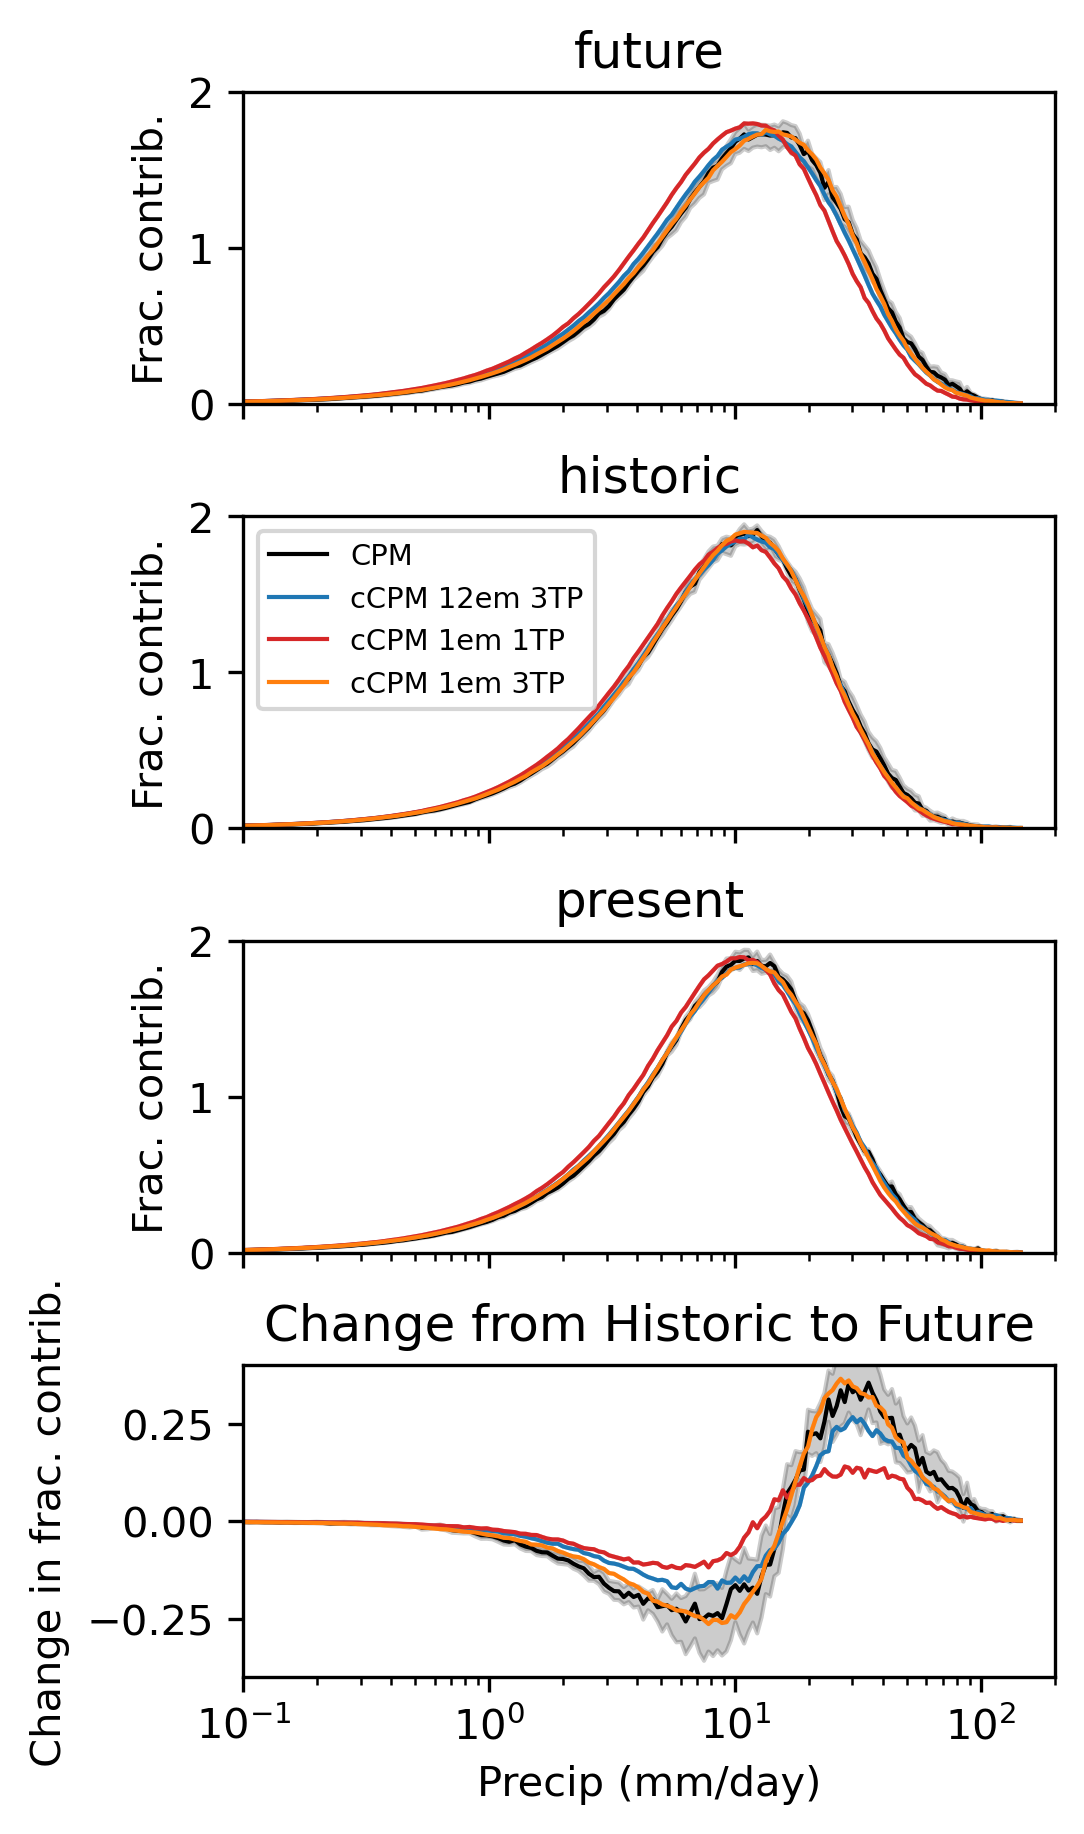

In [ ]:
for var, bs_cpm_da in bs_cpm_das.items():
    
    fcdata = ccs_fc_da(CCS_DS[f"pred_{var}"], bs_cpm_da, extra_cpm_dims=["iteration"])
    
    fig = plt.figure(layout='constrained', figsize=(3.5, 6))
    plot_ccs_fc_figure(fig, fcdata, palette={label: spec["color"] for label, spec in MODELLABEL2SPEC.items()}, errorbar=("pi", 90))
    plt.show()

#### cCPM 12em 3TP

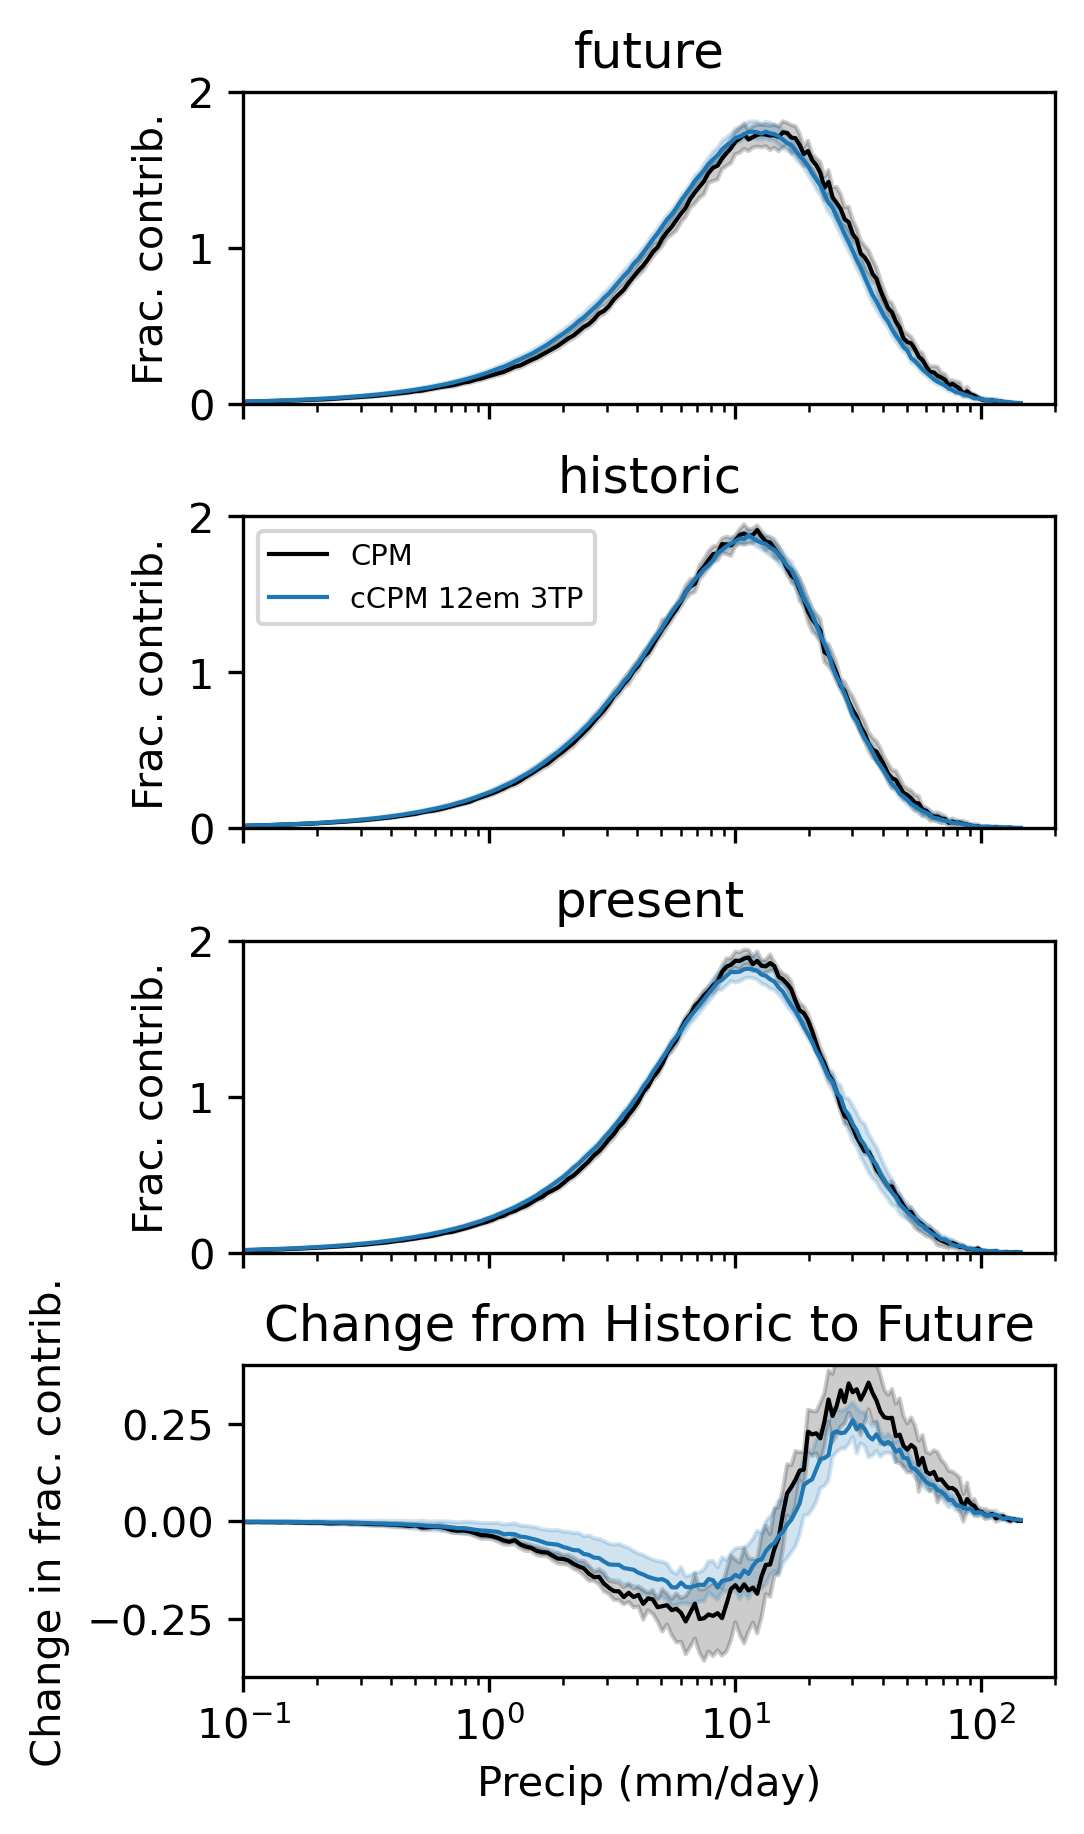

#### cCPM 1em 1TP

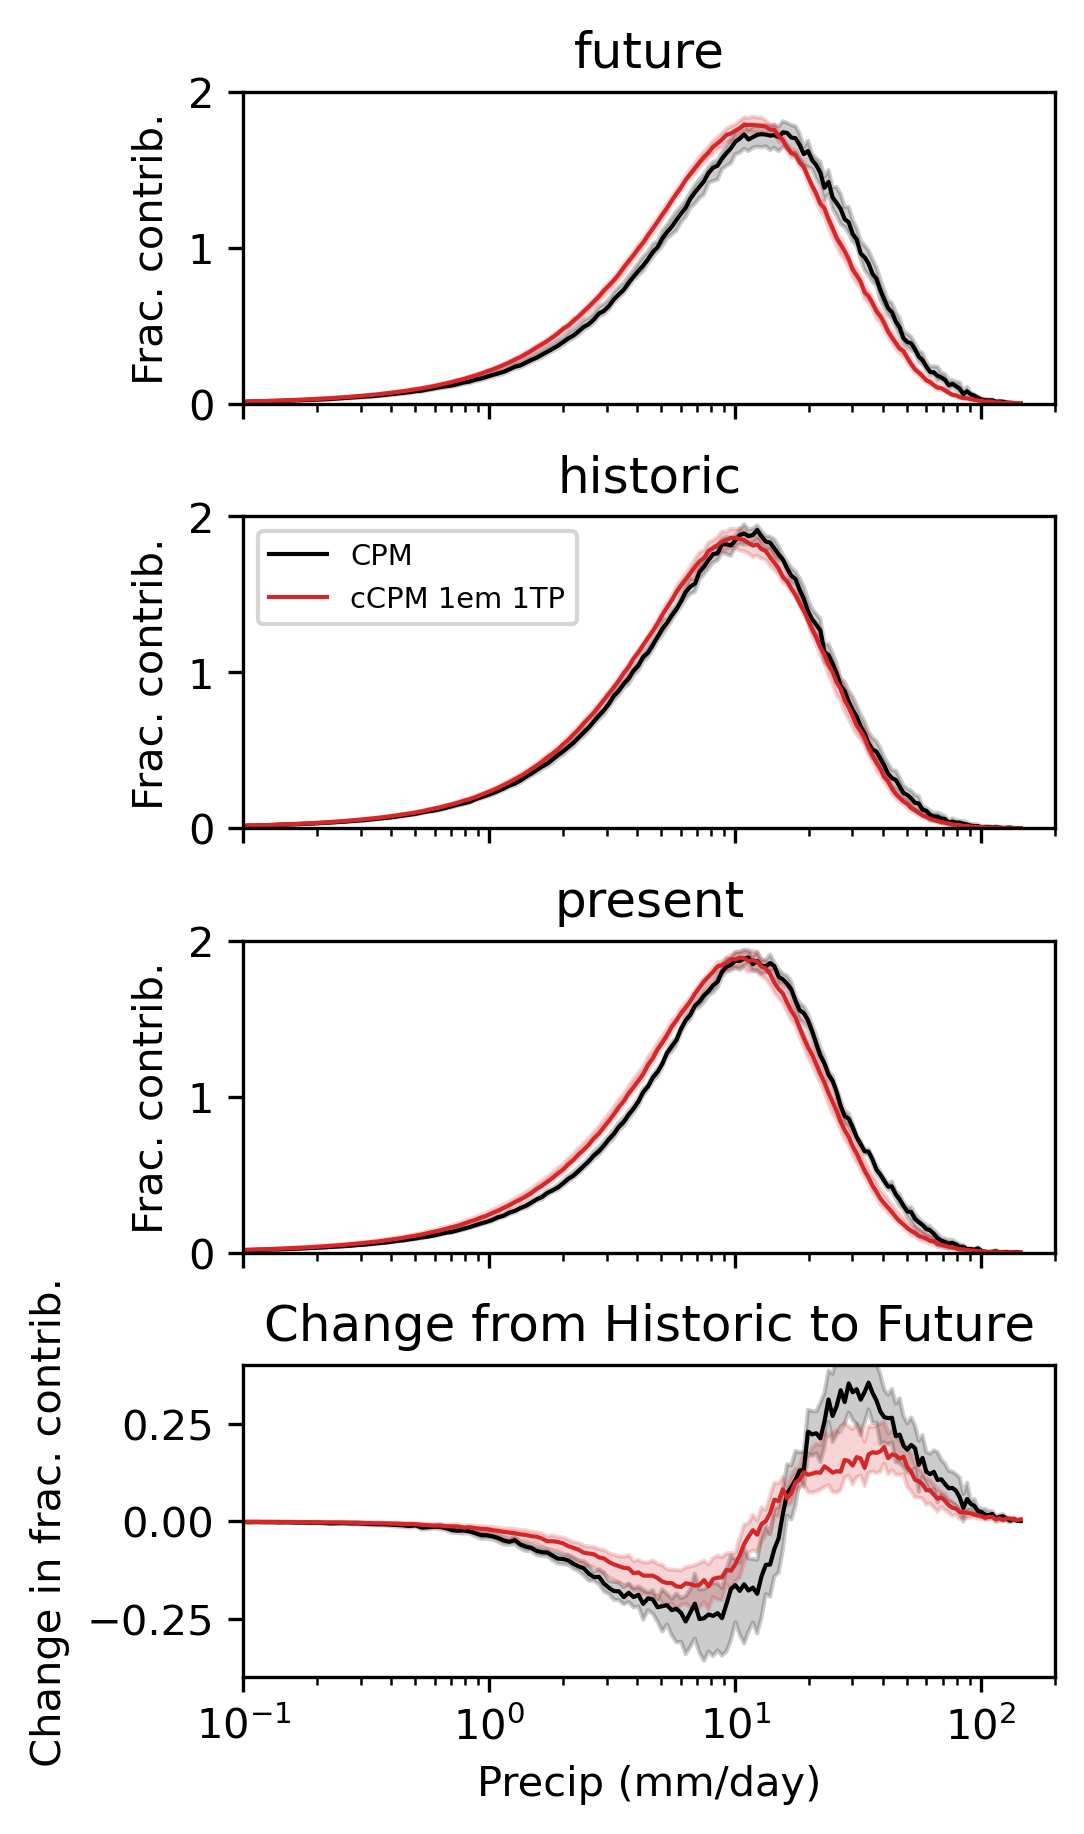

#### cCPM 1em 3TP

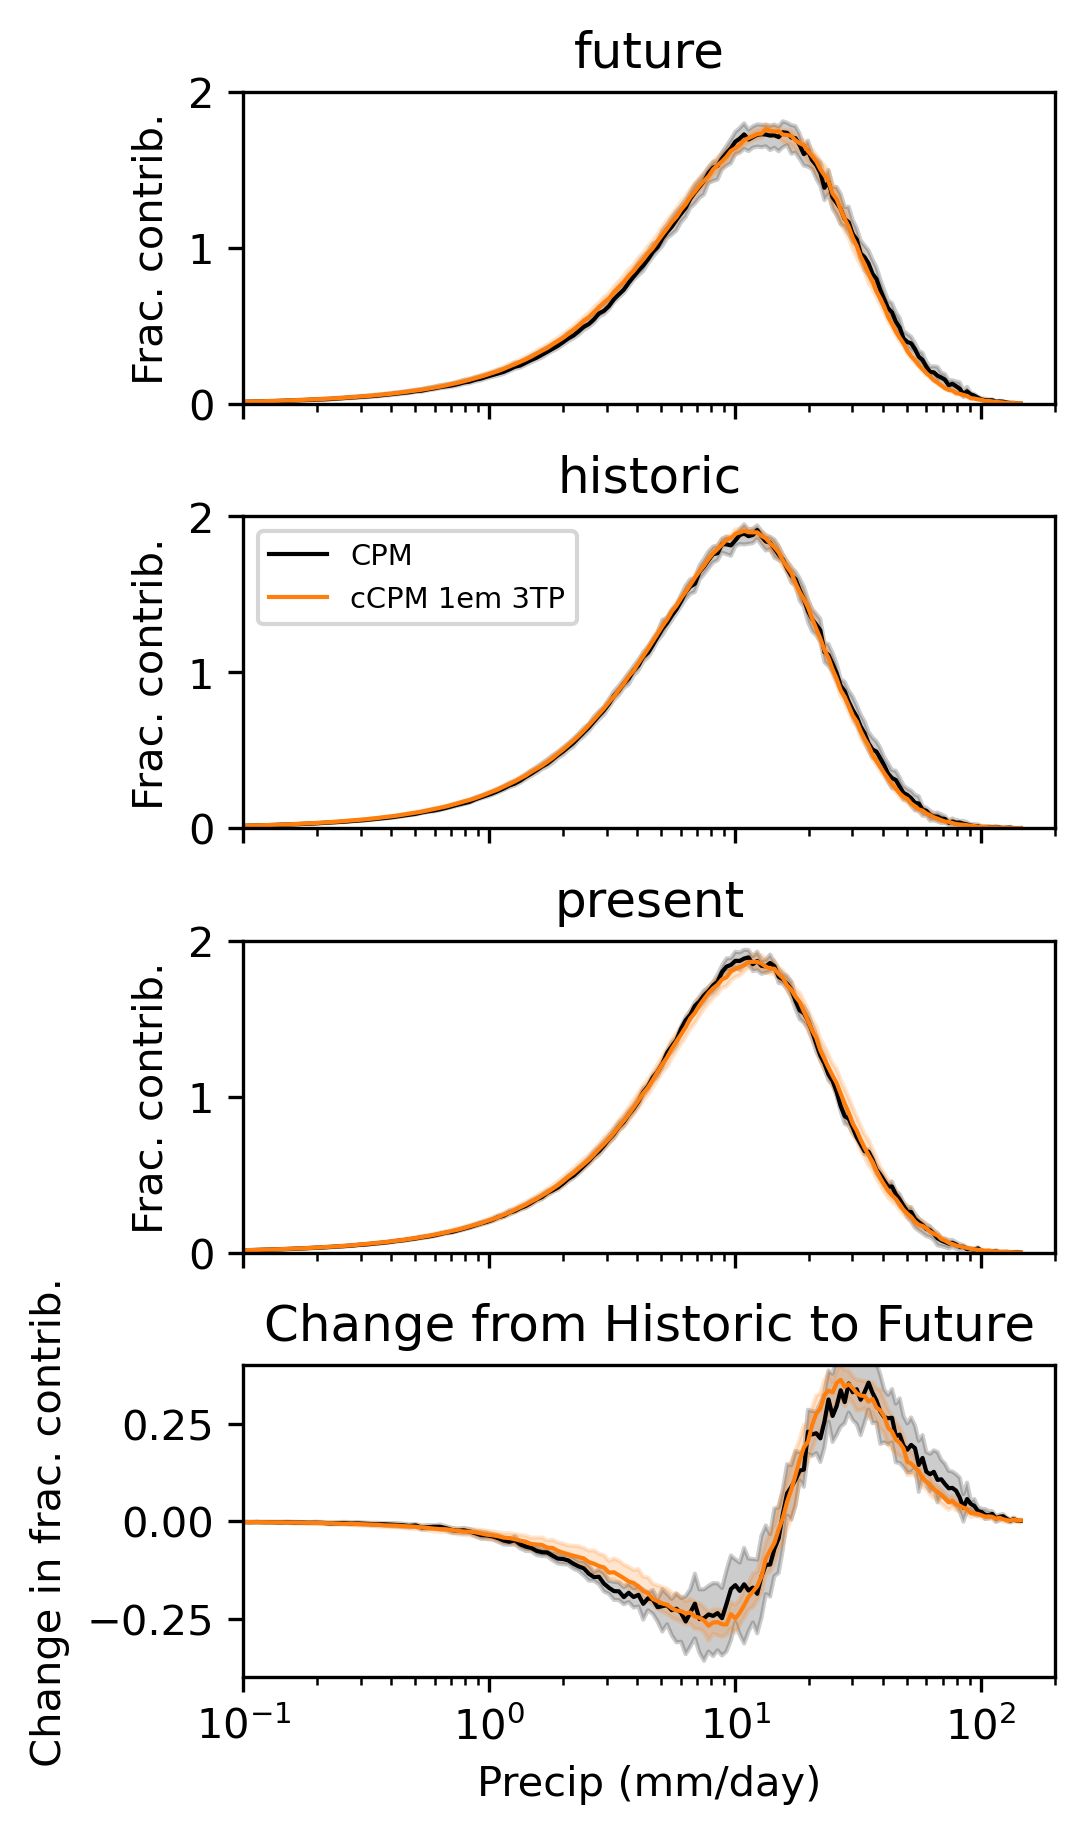

In [ ]:
for var, bs_cpm_da in bs_cpm_das.items():

    for model, model_pred_da in CCS_DS[f"pred_{var}"].groupby("model", squeeze=False):

        IPython.display.display_markdown(f"#### {model}", raw=True)    

        bs_pred_da = chained_groupby_map(model_pred_da.squeeze("model"), ["time_period", "time.season"], resample_examples, niterations=niterations)

        fcdata = ccs_fc_da(bs_pred_da.expand_dims(model=[model]), bs_cpm_da, extra_pred_dims=["iteration"], extra_cpm_dims=["iteration"])
        
        fig = plt.figure(layout='constrained', figsize=(3.5, 6))
        plot_ccs_fc_figure(fig, fcdata, palette={label: spec["color"] for label, spec in MODELLABEL2SPEC.items()}, errorbar=("pi", 90))
        plt.show()
    
        del bs_pred_da

In [ ]:
del bs_cpm_das

#### cCPM 12em 3TP

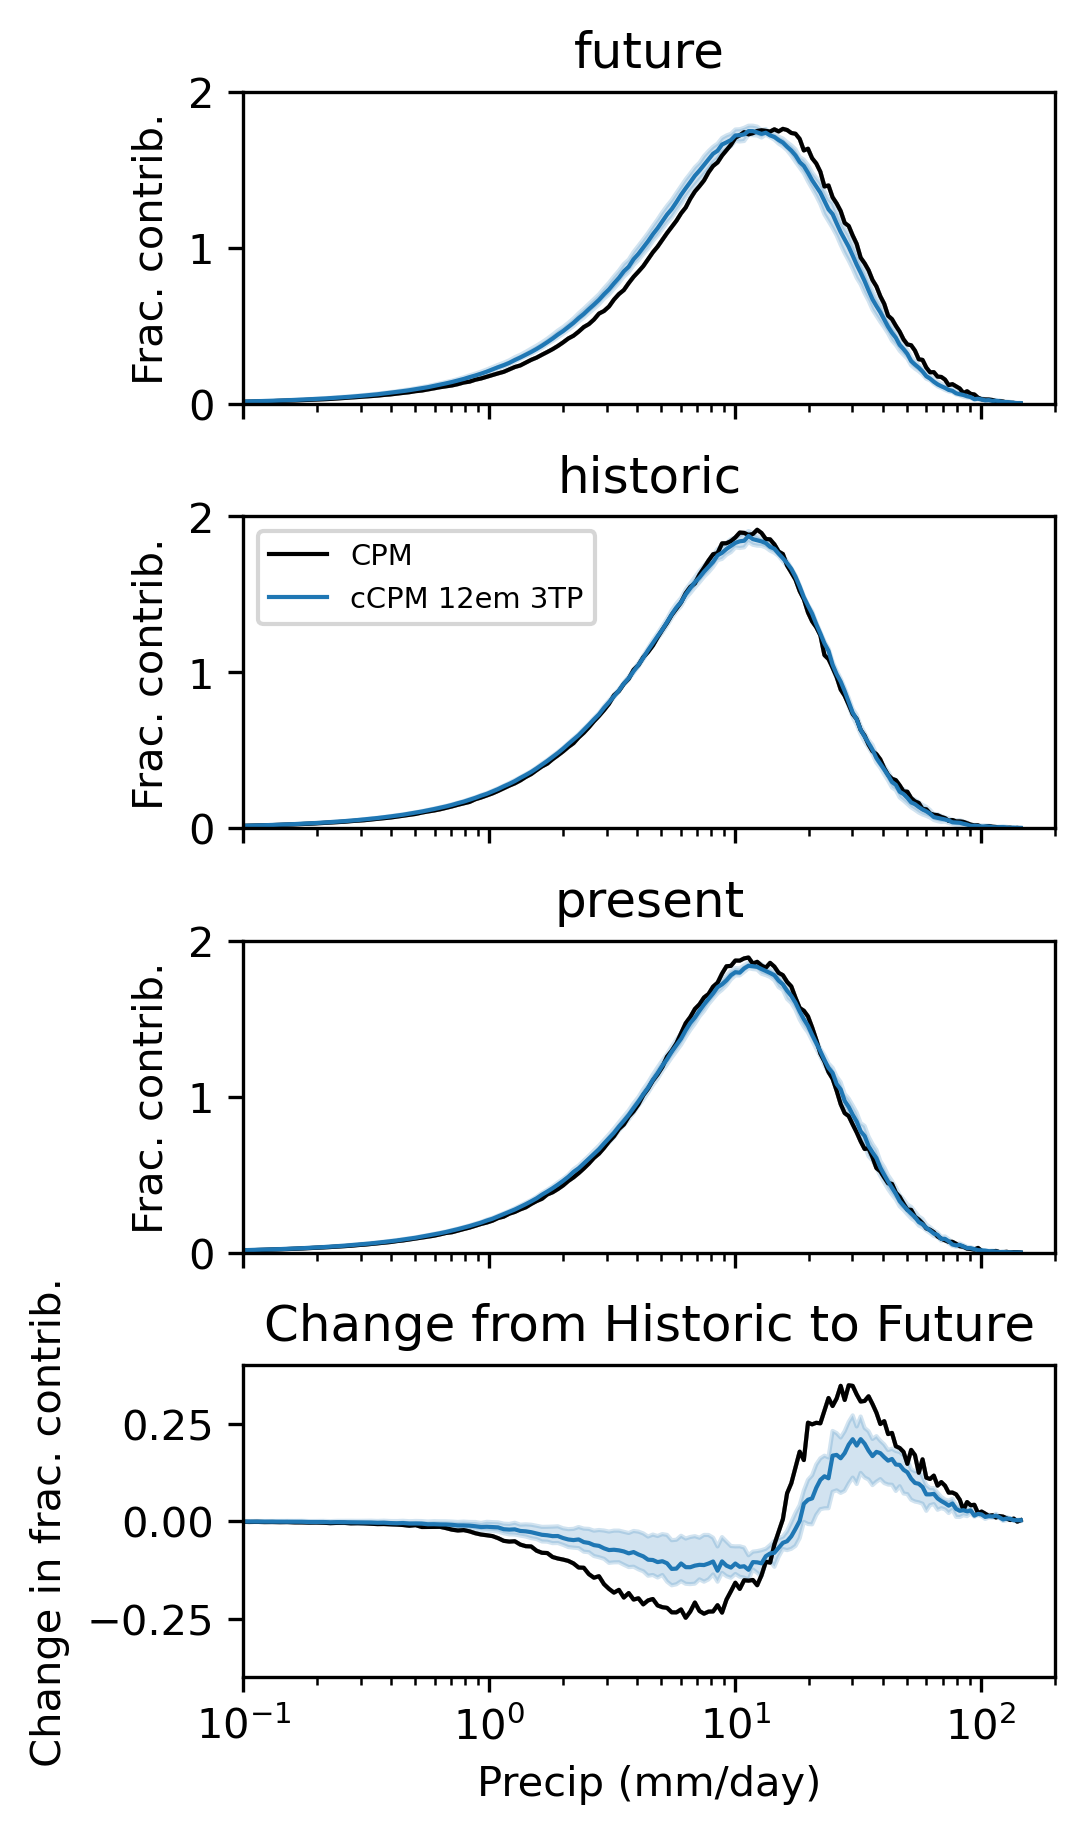

#### cCPM 1em 1TP

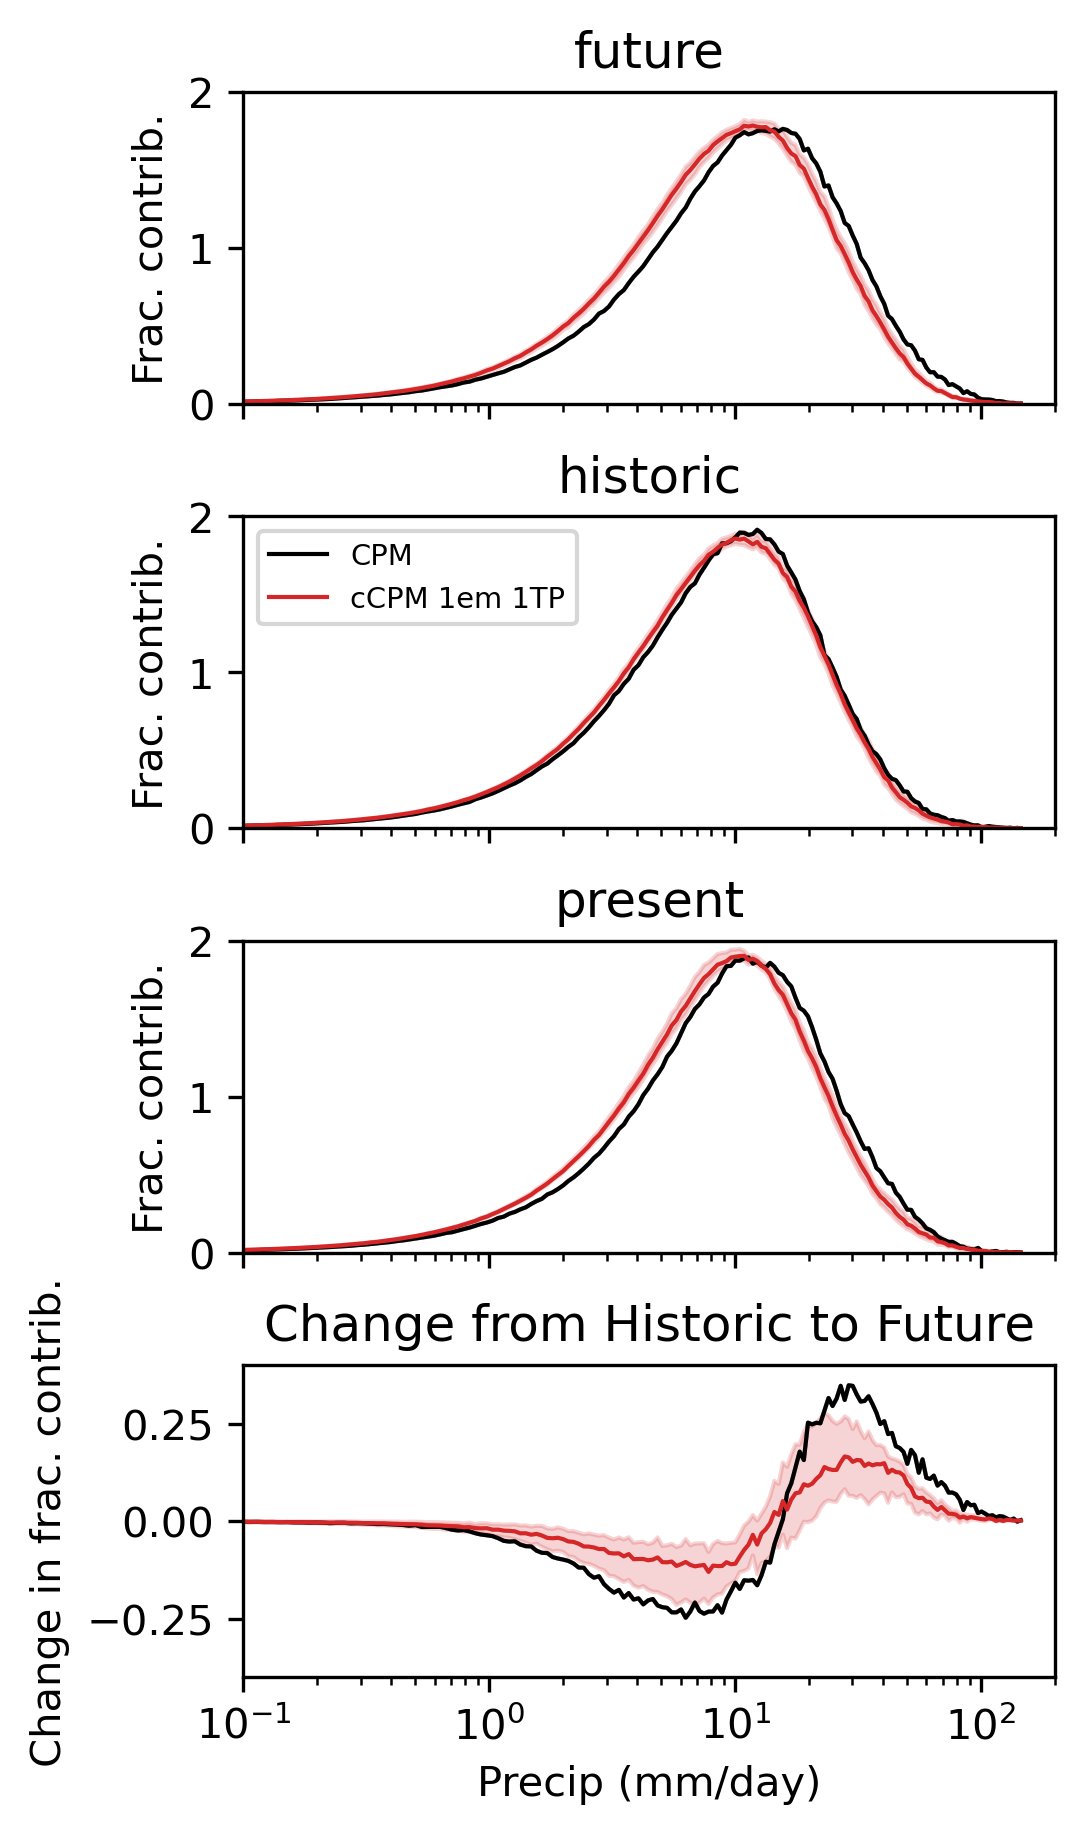

#### cCPM 1em 3TP

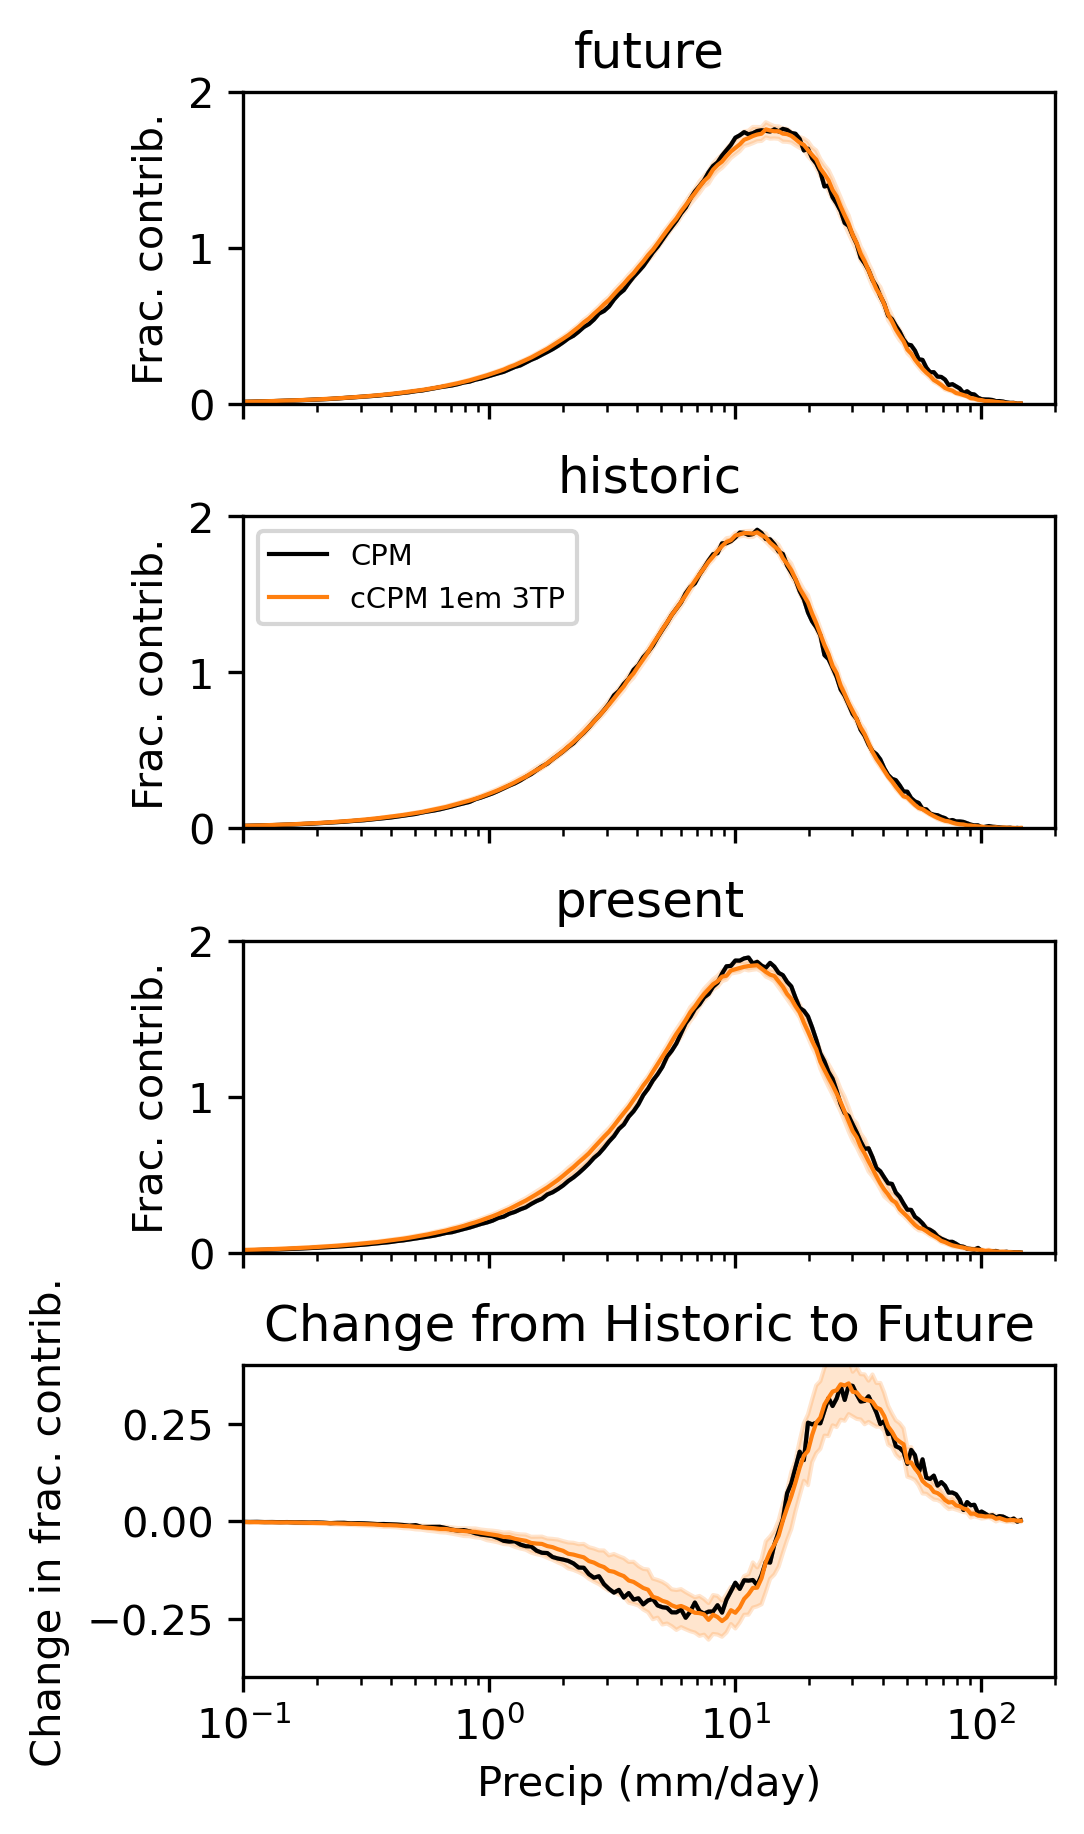

In [ ]:
for var in eval_vars:
    if var not in ["pr"]:
        continue

    for model, model_pred_da in CCS_DS[f"pred_{var}"].groupby("model", squeeze=False):

        IPython.display.display_markdown(f"#### {model}", raw=True)    

        bs_pred_da = chained_groupby_map(model_pred_da.squeeze("model"), ["time_period", "time.season"], resample_examples, niterations=niterations)

        fcdata = ccs_fc_da(bs_pred_da.expand_dims(model=[model]), CCS_DS[f"target_{var}"], extra_pred_dims=["iteration"])
        
        fig = plt.figure(layout='constrained', figsize=(3.5, 6))
        plot_ccs_fc_figure(fig, fcdata, palette={label: spec["color"] for label, spec in MODELLABEL2SPEC.items()}, errorbar=("pi", 90))
        plt.show()
    
        del bs_pred_da